# **ExoplanetHunter**
**Entrega 1 — Análise Exploratória**

## 1. Introdução e problema
A identificação de exoplanetas envolve a análise de sinais que podem indicar planetas orbitando outras estrelas. Pelo método de trânsito, a passagem de um objeto diante de sua estrela provoca uma redução temporária no brilho observado. Sistemas de estrelas binárias, variabilidade estelar e efeitos instrumentais também podem produzir sinais semelhantes, tornando necessária a investigação de falsos positivos.

O ExoplanetHunter investiga características tabulares de objetos de interesse da missão Kepler e de suas estrelas hospedeiras para apoiar essa triagem. Cada linha representa um objeto de interesse; uma estrela pode estar associada a vários objetos. Não processamos diretamente as curvas de luz.

**Problema:** classificação binária, com base em `koi_disposition`: **0 = FALSE POSITIVE** e **1 = CANDIDATE ou CONFIRMED**. O agrupamento permite distinguir os falsos positivos dos candidatos/confirmados do catálogo. Um candidato ainda não é um planeta confirmado; portanto, uma futura previsão positiva não significará confirmação de um planeta.

**Objetivo desta entrega:** caracterizar a base, interpretar distribuições e relações, quantificar problemas e propor hipóteses de pré-processamento. Imputação, remoção de outliers, seleção definitiva de atributos, balanceamento e treinamento ficam para as próximas etapas.


## 2. Fonte e carregamento
Utilizamos a tabela **Kepler Objects of Interest — Cumulative**, disponibilizada pelo **NASA Exoplanet Archive**. Ela reúne dados associados às observações da missão Kepler, incluindo parâmetros de trânsito, estimativas físicas dos objetos e de suas estrelas hospedeiras e classificações do catálogo. Trabalhamos com esses dados tabulares já disponibilizados pelo arquivo, sem realizar observações próprias ou processar diretamente curvas de luz.

Extraimos a tabela pela URL do servico **TAP**, usando a consulta `SELECT * FROM cumulative`, sem filtros, e congelamos a resposta em `data/cumulative.csv` em 30/09/2026. O notebook le essa copia local para manter a analise reprodutivel.

A análise desta entrega se concentra na descrição, visualização e identificação de problemas dos dados, sem aplicar tratamentos. Nas próximas etapas, utilizaremos arquivos CSV para guardar a base utilizada e as versões resultantes do pré-processamento. A consulta remota pode mudar; a copia local registra os dados efetivamente analisados nesta entrega.

Os dados são públicos; seguimos as [orientações de reconhecimento de uso do arquivo](https://exoplanetarchive.ipac.caltech.edu/docs/acknowledge.html), com o DOI **10.26133/NEA4** indicado para a tabela KOI. As definições e unidades dos atributos são consultadas no [dicionário oficial](https://exoplanetarchive.ipac.caltech.edu/docs/API_kepcandidate_columns.html).

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from pathlib import Path

pd.set_option('display.max_columns', 15)
pd.set_option('display.max_rows', 20)
sns.set_theme(style='whitegrid')

arquivo_dados = Path('data/cumulative.csv') if Path('data/cumulative.csv').exists() else Path('../data/cumulative.csv')
df_bruto = pd.read_csv(arquivo_dados)

print(f'Base original: {df_bruto.shape[0]} registros e {df_bruto.shape[1]} colunas.')

Base original: 9564 registros e 153 colunas.


A extração analisada contém **9.564 registros e 153 colunas**. O tamanho da base atende aos requisitos mínimos, mas as 153 colunas incluem identificadores, classificações e metadados, além de possíveis entradas dos modelos. Por isso, não interpretamos esse total como 153 preditores.

## 3. Caracterização da base e do alvo
Examinamos os identificadores, os tipos de armazenamento e as classificações originais antes de definir o alvo binário.

In [ ]:
display(df_bruto[['kepid', 'kepoi_name', 'kepler_name', 'koi_disposition']].head())
print('Estrelas distintas:', df_bruto['kepid'].nunique())
print('Objetos distintos:', df_bruto['kepoi_name'].nunique())
print('Identificadores ausentes:')
print(df_bruto[['kepid', 'kepoi_name']].isna().sum())
print('\nColunas por tipo de armazenamento:')
print(df_bruto.dtypes.value_counts())

,kepid,kepoi_name,kepler_name,koi_disposition
0,10797460,K00752.01,Kepler-227 b,CONFIRMED
1,10797460,K00752.02,Kepler-227 c,CONFIRMED
2,10811496,K00753.01,NaN,CANDIDATE
3,10848459,K00754.01,NaN,FALSE POSITIVE
4,10854555,K00755.01,Kepler-664 b,CONFIRMED


Estrelas distintas: 8214
Objetos distintos: 9564
Identificadores ausentes:
kepid         0
kepoi_name    0
dtype: int64

Colunas por tipo de armazenamento:
float64    127
object      20
int64        6
Name: count, dtype: int64


São **9.564 objetos distintos associados a 8.214 estrelas**, sem ausências nos dois identificadores. Os objetos `K00752.01` e `K00752.02`, por exemplo, compartilham a mesma estrela. A repetição de `kepid` não significa automaticamente uma duplicata. Na avaliação futura, será necessário considerar o agrupamento por estrela para evitar compartilhar características da mesma estrela entre treinamento e avaliação.

O pandas reconheceu 127 colunas `float64`, seis `int64` e 20 `object`. O tipo de armazenamento não determina sozinho o tipo estatístico: um identificador inteiro não é uma medida; uma contagem armazenada com casas decimais continua sendo discreta.

| Exemplos | Significado | Tipo estatístico |
|---|---|---|
| `kepid`, `kepoi_name` | Estrela e objeto | Identificadores |
| `koi_disposition`, `koi_pdisposition` | Classificações do catálogo | Categóricas nominais |
| `koi_count`, `koi_num_transits` | Contagens de candidatos e trânsitos | Numéricas discretas |
| `koi_period`, `koi_duration`, `koi_steff` | Período, duração e temperatura | Numéricas contínuas |
| `koi_time0bk`, `koi_vet_date` | Instante de referência do trânsito e data de atualização | Temporais, armazenadas como número ou texto |
| `koi_fittype`, `koi_sparprov` | Tipo de ajuste e origem dos parâmetros estelares | Categóricas nominais |
| `koi_fpflag_nt` e demais flags de falso positivo | Indicadores de testes de classificação | Categóricas binárias, armazenadas como números |

Não atribuímos uma ordem às classificações. O alvo binário também é nominal, apesar da representação por 0 e 1. Esta tabela apresenta exemplos; os atributos dos gráficos são detalhados adiante.

As demais colunas também cumprem funções diferentes no catálogo:

| Grupo de informações | Exemplos | Papel na análise |
|---|---|---|
| Medidas e estimativas físicas | `koi_period`, `koi_prad`, `koi_smass` | Descrevem o trânsito, o objeto ou a estrela; 12 grandezas recebem exploração detalhada |
| Incertezas das estimativas | `koi_period_err1`, `koi_period_err2` | Ajudam a avaliar a precisão; não são novas medições independentes do mesmo fenômeno |
| Classificações e indicadores de avaliação | `koi_disposition`, `koi_score`, flags | Descrevem a avaliação do objeto e podem revelar informação ligada ao alvo |
| Procedência e métodos de ajuste | `koi_sparprov`, `koi_fittype`, `koi_parm_prov` | Ajudam a compreender como os parâmetros foram obtidos |
| Localização, identificação e documentação | `ra`, `dec`, nomes, comentários e links de relatórios | Permitem localizar e investigar os registros |

Essa organização descreve funções, não uma contagem de grupos exclusivos. Coordenadas em texto, identificadores e comentários não serão tratados como categorias comuns só porque o pandas os armazena como `object`.


,Quantidade,Percentual (%)
koi_disposition,,
FALSE POSITIVE,4839,50.60
CONFIRMED,2748,28.73
CANDIDATE,1977,20.67


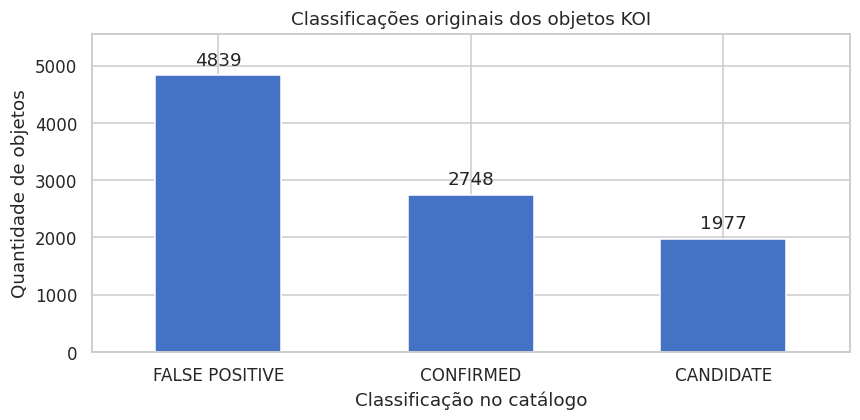

Contagem do alvo binário:
target
0    4839
1    4725
Name: count, dtype: int64
Rótulos sem correspondência no mapeamento: 0


In [ ]:
contagem_classes = df_bruto['koi_disposition'].value_counts(dropna=False)
distribuicao_classes = pd.DataFrame({
    'Quantidade': contagem_classes,
    'Percentual (%)': contagem_classes / len(df_bruto) * 100
})
display(distribuicao_classes.round(2))

ax = contagem_classes.plot.bar(figsize=(8, 4), color='#4472C4', rot=0)
ax.bar_label(ax.containers[0], padding=4)
ax.set_title('Classificações originais dos objetos KOI')
ax.set_xlabel('Classificação no catálogo')
ax.set_ylabel('Quantidade de objetos')
ax.margins(y=0.15)
plt.tight_layout()
plt.show()

df = df_bruto.copy()
mapeamento_alvo = {'FALSE POSITIVE': 0, 'CANDIDATE': 1, 'CONFIRMED': 1}
df['target'] = df['koi_disposition'].map(mapeamento_alvo)
print('Contagem do alvo binário:')
print(df['target'].value_counts().sort_index())
print('Rótulos sem correspondência no mapeamento:', df['target'].isna().sum())

O gráfico mostra **4.839 falsos positivos (50,60%)**, **2.748 confirmados (28,73%)** e **1.977 candidatos (20,67%)**. Após o agrupamento, a classe positiva reúne **4.725 registros (49,40%)**. Não há rótulos sem correspondência nesta extração.

O alvo binário apresenta proporções próximas, sem justificativa inicial para balanceamento. Contudo, candidatos compõem **41,84% da classe positiva**; essa incerteza deve acompanhar a interpretação dos modelos. As proporções descrevem este catálogo, não a frequência de planetas entre todas as estrelas.

### Frequências de outros campos categóricos
Além do alvo, descrevemos três campos nominais relevantes para entender a construção da base: `koi_pdisposition` (classificação com dados Kepler), `koi_fittype` (tipo de ajuste dos parâmetros) e `koi_sparprov` (origem dos parâmetros estelares). As definições seguem o [dicionário da NASA](https://exoplanetarchive.ipac.caltech.edu/docs/API_kepcandidate_columns.html).

As porcentagens usam todos os 9.564 registros como denominador, incluindo ausências. Esses campos complementam a caracterização; não são acrescentados aos 12 atributos físicos. A classificação original e o alvo já foram examinados acima.

In [ ]:
colunas_categoricas = ['koi_pdisposition', 'koi_fittype', 'koi_sparprov']
tabelas_frequencias = []

for coluna in colunas_categoricas:
    contagem = df_bruto[coluna].value_counts(dropna=False)
    tabela = pd.DataFrame({
        'Atributo': coluna,
        'Categoria': contagem.index,
        'Quantidade': contagem.values,
        'Percentual (%)': contagem.values / len(df_bruto) * 100
    })
    tabelas_frequencias.append(tabela)

frequencias_categoricas = pd.concat(tabelas_frequencias, ignore_index=True)
display(frequencias_categoricas.round(2))

,Atributo,Categoria,Quantidade,Percentual (%)
0,koi_pdisposition,FALSE POSITIVE,4847,50.68
1,koi_pdisposition,CANDIDATE,4717,49.32
2,koi_fittype,LS+MCMC,7897,82.57
3,koi_fittype,MCMC,1206,12.61
4,koi_fittype,none,369,3.86
5,koi_fittype,LS,92,0.96
6,koi_sparprov,q1_q17_dr25_stellar,7907,82.67
7,koi_sparprov,stellar_q1_q16,956,10.00
8,koi_sparprov,NaN,363,3.80
9,koi_sparprov,stellar_q1_q17,233,2.44


- **Classificação Kepler:** `koi_pdisposition` contém 4.847 falsos positivos (50,68%) e 4.717 candidatos (49,32%). Ela não separa confirmados nesta extração e suas contagens diferem das do alvo agrupado. É uma informação de classificação já produzida pelo catálogo; usá-la para prever esse alvo poderia introduzir vazamento de informação.
- **Tipo de ajuste:** `LS+MCMC` reúne 7.897 registros (82,57%), seguido de `MCMC`, com 1.206 (12,61%), `none`, com 369 (3,86%), e `LS`, com 92 (0,96%). O predomínio de um método não significa que todos os parâmetros tenham sido obtidos da mesma forma. `none` é uma categoria registrada no catálogo para ajuste não fornecido, não um valor `NaN`; sua relação com as ausências merece investigação antes de definir uma imputação.
- **Origem dos parâmetros estelares:** `q1_q17_dr25_stellar` reúne 7.907 registros (82,67%). Há outras origens e 363 ausências (3,80%). Essa diversidade deve ser considerada ao examinar diferenças e extremos: o campo descreve a procedência, não uma ordem de qualidade das estimativas.

Não aplicamos codificação desses campos nesta EDA. Se algum deles for justificado como entrada futuramente, será necessário avaliar sua disponibilidade na previsão e uma representação sem ordem artificial, como one-hot. Os 12 atributos da exploração detalhada são contínuos e não exigem essa codificação.

## 4. Atributos para a exploração detalhada
Exploramos em detalhe **12 atributos físicos e observacionais**, organizados em três grupos relacionados ao problema:

- **Trânsito:** período, impacto, duração e profundidade descrevem a repetição, a geometria e a intensidade do sinal.
- **Objeto e sinal:** raio estimado, temperatura de equilíbrio, insolação e sinal-ruído permitem investigar as estimativas associadas ao objeto e a intensidade do sinal em relação ao ruído.
- **Estrela hospedeira:** temperatura, gravidade superficial, raio e magnitude caracterizam a estrela à qual o sinal está associado.

O recorte reúne grandezas com significado interpretável e permite comparar suas distribuições e relações com a classificação do catálogo. Mantemos os atributos da versão inicial por essa pertinência ao problema; não os escolhemos a partir de desempenho de modelos. Outras medidas, incertezas e metadados ficam fora da exploração detalhada nesta entrega, sem serem considerados automaticamente irrelevantes.

As estatísticas, os histogramas, os boxplots, as correlações e a investigação de extremos se referem a esses 12 atributos. As verificações de ausências, constantes e duplicação abrangem as 153 colunas originais. A caracterização categórica complementar descreve campos de classificação, ajuste e procedência. A lista abaixo organiza a exploração, **sem excluir colunas de `df_bruto` ou de `df` e sem representar uma seleção definitiva de preditores**. Os mínimos do projeto são limites inferiores, não metas.

| Atributo | Significado | Unidade |
|---|---|---|
| `koi_period` | Período orbital | Dias |
| `koi_impact` | Distância projetada no trânsito, normalizada pelo raio estelar | Adimensional |
| `koi_duration` | Duração do trânsito | Horas |
| `koi_depth` | Profundidade do trânsito | ppm |
| `koi_prad` | Raio estimado do objeto sob a hipótese planetária | Raios terrestres |
| `koi_teq` | Temperatura de equilíbrio estimada | K |
| `koi_steff` | Temperatura efetiva da estrela | K |
| `koi_slogg` | Logaritmo decimal da gravidade superficial estelar | log10(cm/s²) |
| `koi_srad` | Raio da estrela | Raios solares |
| `koi_insol` | Fluxo de insolação estimado | Fluxo recebido pela Terra |
| `koi_model_snr` | Relação sinal-ruído do trânsito | Adimensional |
| `koi_kepmag` | Magnitude aparente Kepler | mag |

Essas variáveis são quantitativas contínuas. Alguns parâmetros são estimados a partir de ajustes, inclusive para falsos positivos; seus nomes não comprovam a existência de um planeta.

Identificadores não serão preditores. `koi_disposition` determina o alvo e não pode entrar em um modelo que o prevê. Campos como `koi_pdisposition`, `koi_score`, flags de falso positivo, `koi_comment` e `kepler_name` também exigem cautela por conterem informações ligadas à classificação. Isso não significa que todas as outras colunas causem vazamento. A disponibilidade de cada entrada no momento pretendido da previsão deverá ser verificada na próxima etapa.

In [ ]:
colunas_fisicas = [
    'koi_period', 'koi_impact', 'koi_duration', 'koi_depth',
    'koi_prad', 'koi_teq', 'koi_steff', 'koi_slogg',
    'koi_srad', 'koi_insol', 'koi_model_snr', 'koi_kepmag'
]

print('Registros preservados:', len(df))
print('Atributos físicos examinados:', len(colunas_fisicas))
print('Mínimos atendidos:', len(df) >= 1001 and len(colunas_fisicas) >= 11)

unidades = {
    'koi_period': 'dias', 'koi_impact': 'adimensional',
    'koi_duration': 'horas', 'koi_depth': 'ppm',
    'koi_prad': 'raios terrestres', 'koi_teq': 'K',
    'koi_steff': 'K', 'koi_slogg': 'log10(cm/s²)',
    'koi_srad': 'raios solares', 'koi_insol': 'fluxo terrestre',
    'koi_model_snr': 'adimensional', 'koi_kepmag': 'mag'
}

Registros preservados: 9564
Atributos físicos examinados: 12
Mínimos atendidos: True


## 5. Estatísticas e distribuições
O resumo apresenta contagem de valores observados, média, desvio-padrão, mínimo, quartis e máximo. A coluna `50%` é a mediana. As estatísticas desconsideram valores ausentes; por isso, a contagem pode variar entre atributos.

In [ ]:
estatisticas = df[colunas_fisicas].describe().T
display(estatisticas.round(3))

,count,mean,std,min,25%,50%,75%,max
koi_period,9564.0,75.671,1334.744,0.242,2.734,9.753,40.715,1.299958e+05
koi_impact,9201.0,0.735,3.349,0.000,0.197,0.537,0.889,1.008060e+02
koi_duration,9564.0,5.622,6.472,0.052,2.438,3.793,6.276,1.385400e+02
koi_depth,9201.0,23791.344,82242.685,0.000,159.900,421.100,1473.400,1.541400e+06
koi_prad,9201.0,102.892,3077.639,0.080,1.400,2.390,14.930,2.003460e+05
koi_teq,9201.0,1085.386,856.351,25.000,539.000,878.000,1379.000,1.466700e+04
koi_steff,9201.0,5706.823,796.858,2661.000,5310.000,5767.000,6112.000,1.589600e+04
koi_slogg,9201.0,4.310,0.433,0.047,4.218,4.438,4.543,5.364000e+00
koi_srad,9201.0,1.729,6.127,0.109,0.829,1.000,1.345,2.299080e+02
koi_insol,9243.0,7745.737,159204.665,0.000,20.150,141.600,870.290,1.094755e+07


O período orbital tem média de **75,67 dias** e mediana de **9,75 dias**, com máximo próximo de **129.996 dias**. A diferença entre média e mediana sugere influência de uma cauda superior extensa.

O raio estimado apresenta mediana de **2,39 raios terrestres**, mas máximo de **200.346 raios terrestres**. Esse extremo merece inspeção do registro e do ajuste; não deve ser aceito como dimensão comprovada de um planeta. As escalas também variam muito entre atributos, o que motiva avaliar escalonamento posteriormente.

### Histogramas e boxplots
Organizamos os 12 atributos em três grupos. Para variáveis com caudas muito extensas, mostramos **log10(1 + valor)** apenas nos gráficos. Essa expressão preserva os zeros e facilita observar a distribuição; a base e a tabela de estatísticas continuam na escala original. O deslocamento de 1 usa a unidade indicada para cada variável.

Os gráficos utilizam os valores presentes, sem imputação. As contagens de ausências aparecem no diagnóstico. Pontos fora dos bigodes são sinais estatísticos para investigar, não erros automaticamente. Nos painéis transformados, os bigodes são calculados na escala mostrada; a quantificação pelo IQR na escala original será feita separadamente.

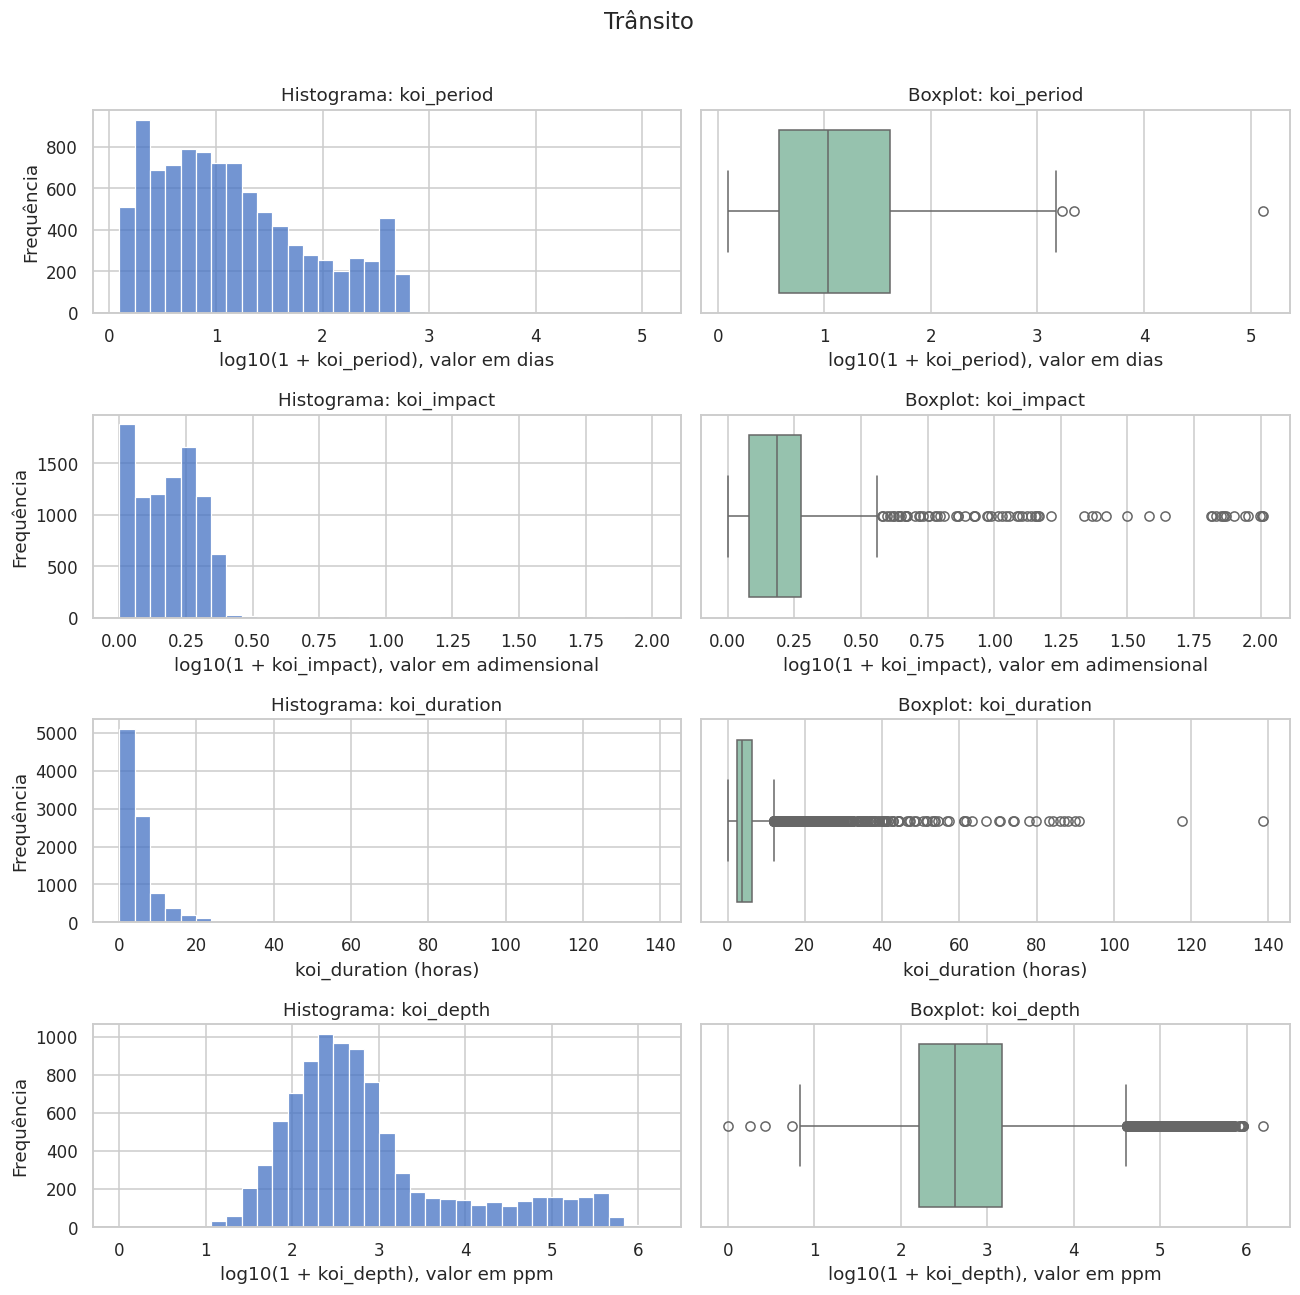

In [ ]:
grupo = ['koi_period', 'koi_impact', 'koi_duration', 'koi_depth']
colunas_log = ['koi_period', 'koi_impact', 'koi_depth', 'koi_prad',
               'koi_teq', 'koi_insol', 'koi_model_snr', 'koi_srad']

fig, eixos = plt.subplots(4, 2, figsize=(12, 12))
for i, coluna in enumerate(grupo):
    valores = df[coluna].dropna()
    rotulo = f'{coluna} ({unidades[coluna]})'
    if coluna in colunas_log:
        valores = np.log10(1 + valores)
        rotulo = f'log10(1 + {coluna}), valor em {unidades[coluna]}'
    sns.histplot(x=valores, bins=35, color='#4472C4', ax=eixos[i, 0])
    sns.boxplot(x=valores, color='#8FC9AE', ax=eixos[i, 1])
    eixos[i, 0].set_title(f'Histograma: {coluna}')
    eixos[i, 1].set_title(f'Boxplot: {coluna}')
    eixos[i, 0].set_ylabel('Frequência')
    for eixo in eixos[i]:
        eixo.set_xlabel(rotulo)
fig.suptitle('Trânsito', fontsize=15)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

- **Período orbital:** a escala logarítmica permite enxergar a região que ficava comprimida pelos extremos. Média muito acima da mediana e máximo elevado indicam cauda à direita; uma transformação de escala poderá ser avaliada no pré-processamento.
- **Parâmetro de impacto:** a mediana é 0,537, mas há valores acima de 100. Esses extremos devem ser examinados considerando a definição geométrica e o ajuste, sem usar automaticamente um corte em 1. Na modelagem, um corte sem análise poderia descartar características úteis para reconhecer falsos positivos.
- **Duração:** metade dos valores observados fica entre aproximadamente 2,44 e 6,28 horas; a cauda superior chega a 138,54 horas. O comportamento motiva investigar trânsitos muito longos e sua classificação.
- **Profundidade:** a mediana é 421,1 ppm e a média é 23.791,34 ppm. A assimetria e os extremos justificam olhar a distribuição por classe e checar a coerência dos maiores valores.

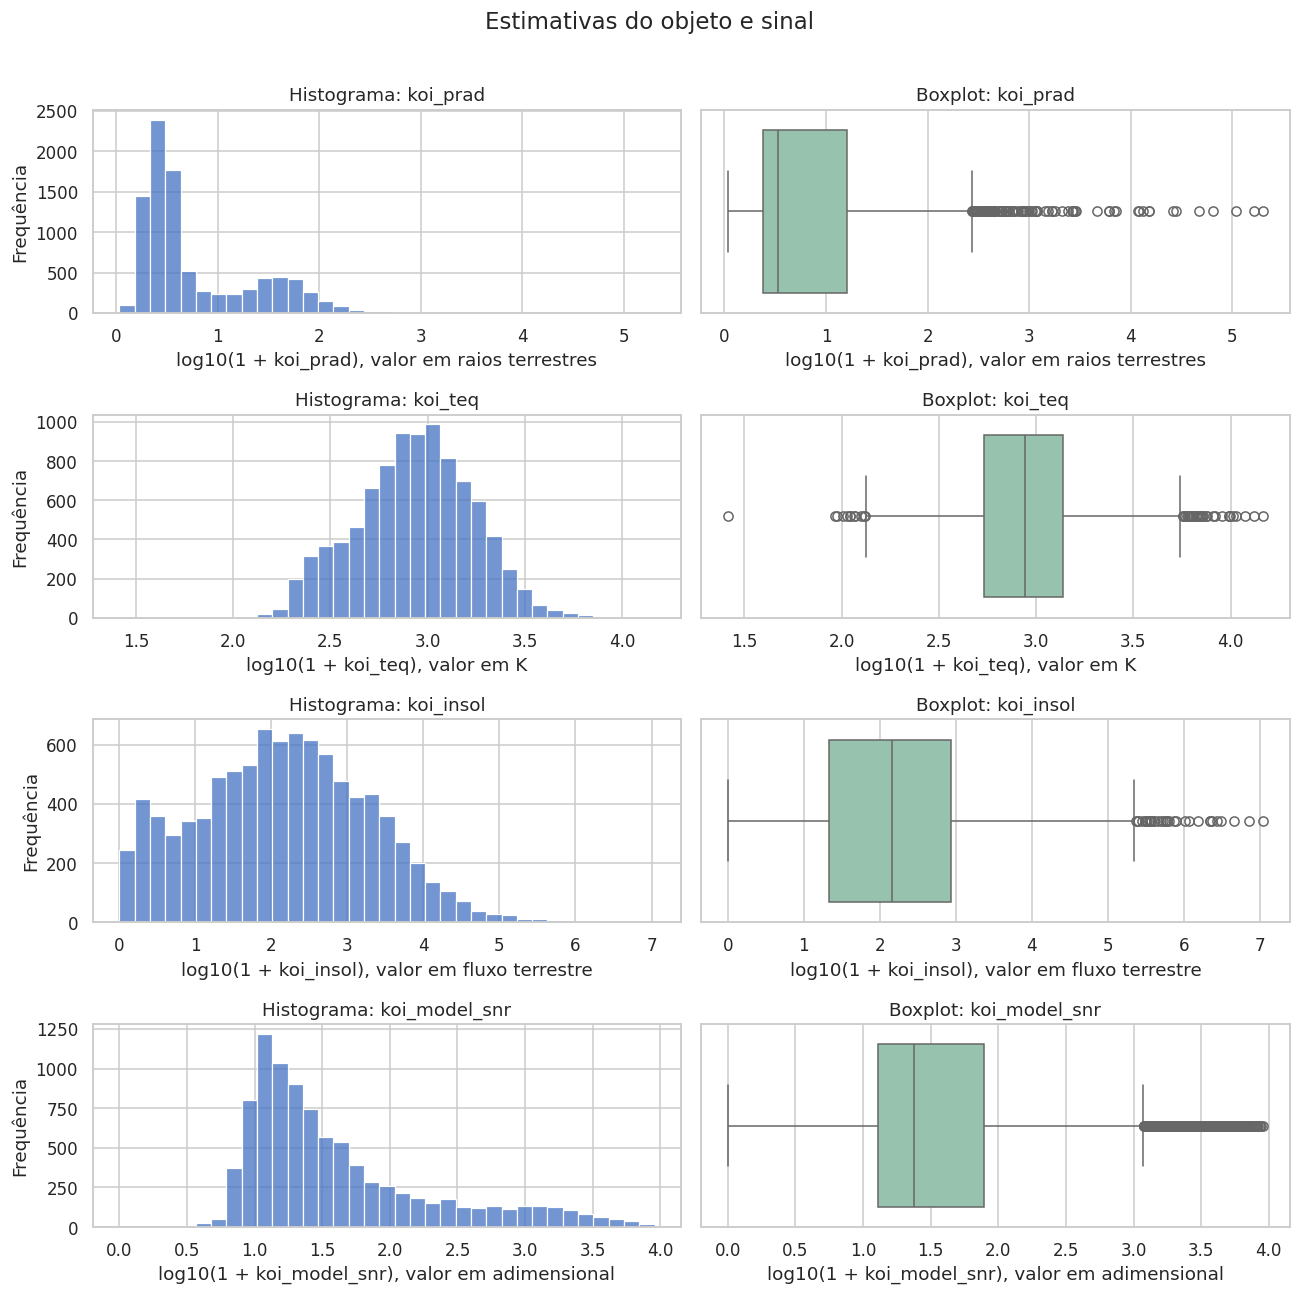

In [ ]:
grupo = ['koi_prad', 'koi_teq', 'koi_insol', 'koi_model_snr']
colunas_log = ['koi_period', 'koi_impact', 'koi_depth', 'koi_prad',
               'koi_teq', 'koi_insol', 'koi_model_snr', 'koi_srad']

fig, eixos = plt.subplots(4, 2, figsize=(12, 12))
for i, coluna in enumerate(grupo):
    valores = df[coluna].dropna()
    rotulo = f'{coluna} ({unidades[coluna]})'
    if coluna in colunas_log:
        valores = np.log10(1 + valores)
        rotulo = f'log10(1 + {coluna}), valor em {unidades[coluna]}'
    sns.histplot(x=valores, bins=35, color='#4472C4', ax=eixos[i, 0])
    sns.boxplot(x=valores, color='#8FC9AE', ax=eixos[i, 1])
    eixos[i, 0].set_title(f'Histograma: {coluna}')
    eixos[i, 1].set_title(f'Boxplot: {coluna}')
    eixos[i, 0].set_ylabel('Frequência')
    for eixo in eixos[i]:
        eixo.set_xlabel(rotulo)
fig.suptitle('Estimativas do objeto e sinal', fontsize=15)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

- **Raio estimado:** a concentração central convive com estimativas muito grandes. Como a base inclui falsos positivos, não interpretamos todos esses valores como raios de planetas reais. O efeito dos extremos nas estatísticas deve ser considerado antes de escolher o escalonamento e um eventual tratamento de outliers.
- **Temperatura de equilíbrio:** a mediana é 878 K e a média é 1.085,39 K, com cauda superior extensa. Valores típicos e extremos devem ser comparados entre as classes; a distribuição isolada não mostra se esse atributo distingue candidatos de falsos positivos.
- **Insolação:** a média é 7.745,74 vezes o fluxo terrestre, muito acima da mediana de 141,6. A escala visual evidencia a amplitude de valores; o atributo também deve ser examinado quanto à informação compartilhada com a temperatura estimada.
- **Sinal-ruído:** a mediana é 23 e a média é 259,90. Há sinais muito intensos, mas intensidade não comprova origem planetária; falsos positivos também podem produzir sinais fortes. Por isso, a modelagem deve avaliar esse atributo em conjunto com outras características, sem pressupor um limiar que confirme planetas.

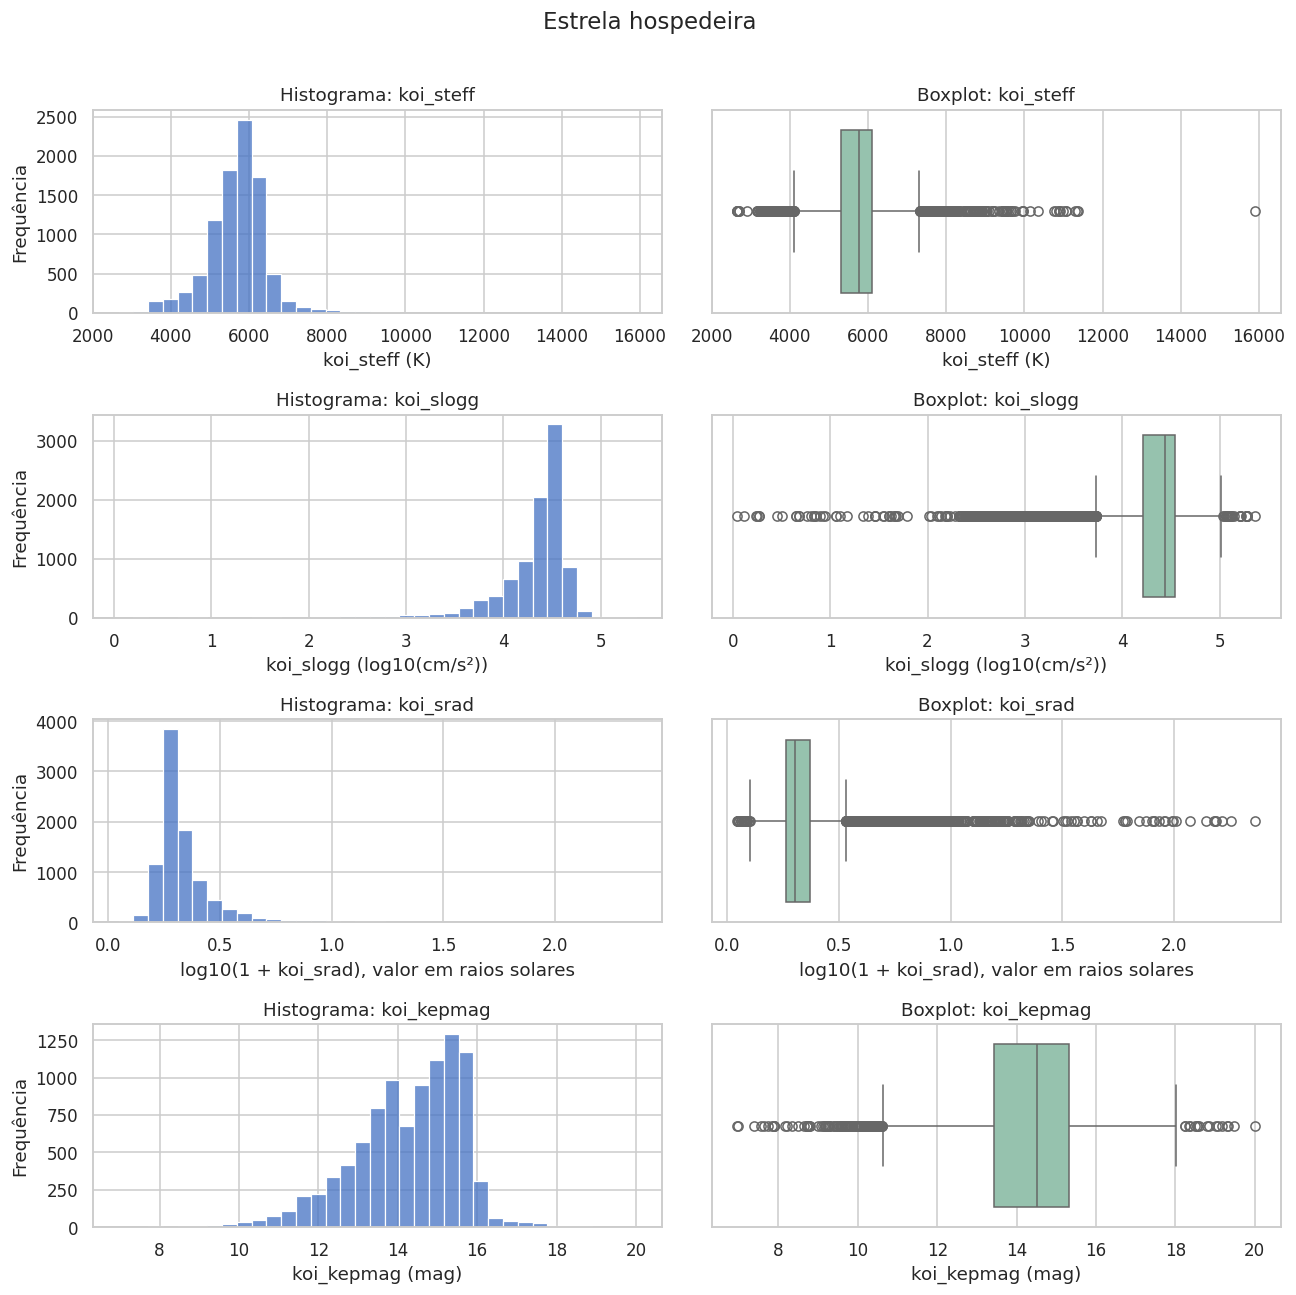

In [ ]:
grupo = ['koi_steff', 'koi_slogg', 'koi_srad', 'koi_kepmag']
colunas_log = ['koi_period', 'koi_impact', 'koi_depth', 'koi_prad',
               'koi_teq', 'koi_insol', 'koi_model_snr', 'koi_srad']

fig, eixos = plt.subplots(4, 2, figsize=(12, 12))
for i, coluna in enumerate(grupo):
    valores = df[coluna].dropna()
    rotulo = f'{coluna} ({unidades[coluna]})'
    if coluna in colunas_log:
        valores = np.log10(1 + valores)
        rotulo = f'log10(1 + {coluna}), valor em {unidades[coluna]}'
    sns.histplot(x=valores, bins=35, color='#4472C4', ax=eixos[i, 0])
    sns.boxplot(x=valores, color='#8FC9AE', ax=eixos[i, 1])
    eixos[i, 0].set_title(f'Histograma: {coluna}')
    eixos[i, 1].set_title(f'Boxplot: {coluna}')
    eixos[i, 0].set_ylabel('Frequência')
    for eixo in eixos[i]:
        eixo.set_xlabel(rotulo)
fig.suptitle('Estrela hospedeira', fontsize=15)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

- **Temperatura estelar:** os valores centrais se concentram perto de 5.000–6.000 K, com mediana de 5.767 K. Há observações afastadas em ambas as direções; isso não implica que toda estrela mais fria ou mais quente seja um erro. Uma remoção automática poderia reduzir a diversidade de estrelas representadas no treinamento.
- **Gravidade superficial:** a mediana é 4,438 e a média é 4,310, com cauda inferior. A variável já está expressa em logaritmo; não aplicamos outro logaritmo no gráfico. No pré-processamento, isso precisa ser considerado para evitar transformar todas as colunas pela mesma regra; a relação com o raio estelar também pode indicar informação compartilhada.
- **Raio estelar:** a mediana é um raio solar, enquanto a média é 1,73 e o máximo é 229,91. A presença de estrelas maiores contribui para a cauda; será importante avaliar a relação com a gravidade superficial antes de decidir se os dois atributos acrescentam informação complementar à modelagem.
- **Magnitude Kepler:** a mediana é 14,52 mag. O histograma concentra observações aproximadamente entre 14 e 16 mag, com cauda em direção aos valores menores. O boxplot também sinaliza observações afastadas nos dois extremos. Magnitude é uma escala em que valores menores correspondem a maior brilho aparente; não se deve interpretar uma magnitude maior como maior brilho. A distribuição isolada não demonstra capacidade de separar as classes; sua contribuição precisa ser avaliada em relação ao alvo e aos demais atributos.

## 6. Relações entre variáveis
### Correlação entre atributos e com o alvo
O heatmap de Pearson mede associações lineares. Incluímos os 12 atributos e `target`, excluindo identificadores e o rótulo original. Para o alvo 0/1, um sinal negativo indica que valores maiores do atributo tendem a estar associados à classe 0. Correlação não demonstra causalidade e não comprova utilidade preditiva isoladamente.

Como existem extremos e relações possivelmente não lineares, usamos Spearman como complemento na identificação de pares associados. Spearman compara a ordenação dos valores. Os cálculos utilizam pares com dados presentes; as quantidades de observações podem variar.

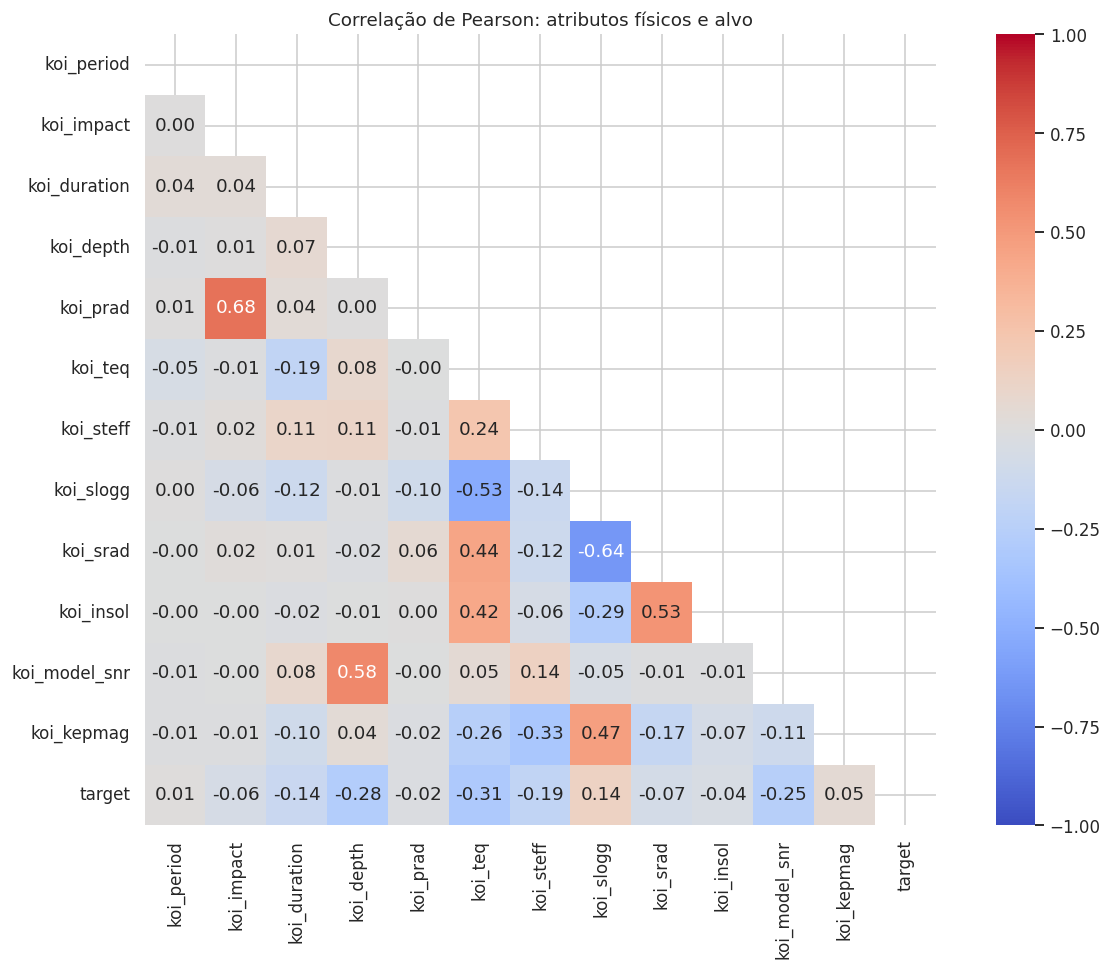

Pares com |Spearman| >= 0,80 (critério exploratório):


,Atributo 1,Atributo 2,Pearson,Spearman
0,koi_period,koi_teq,-0.049,-0.896
1,koi_period,koi_insol,-0.003,-0.896
2,koi_depth,koi_prad,0.003,0.803
3,koi_teq,koi_insol,0.423,1.000
4,koi_slogg,koi_srad,-0.639,-0.980


In [ ]:
matriz_correlacao = df[colunas_fisicas + ['target']].corr()
mascara = np.triu(np.ones_like(matriz_correlacao, dtype=bool))

plt.figure(figsize=(12, 9))
sns.heatmap(matriz_correlacao, mask=mascara, annot=True, fmt='.2f',
            cmap='coolwarm', vmin=-1, vmax=1, square=True)
plt.title('Correlação de Pearson: atributos físicos e alvo')
plt.tight_layout()
plt.show()

correlacao_spearman = df[colunas_fisicas].corr(method='spearman')
pares = []
for i in range(len(colunas_fisicas)):
    for j in range(i + 1, len(colunas_fisicas)):
        a = colunas_fisicas[i]
        b = colunas_fisicas[j]
        valor = correlacao_spearman.loc[a, b]
        if abs(valor) >= 0.80:
            pares.append({'Atributo 1': a, 'Atributo 2': b,
                          'Pearson': matriz_correlacao.loc[a, b],
                          'Spearman': valor})
print('Pares com |Spearman| >= 0,80 (critério exploratório):')
display(pd.DataFrame(pares).round(3))

O heatmap apresenta associações como **impacto × raio estimado (0,68)**, **gravidade × raio estelar (−0,64)** e **profundidade × sinal-ruído (0,58)**. Com o alvo, destacam-se temperatura de equilíbrio (−0,31), profundidade (−0,28) e sinal-ruído (−0,25). Como a classe 0 representa falsos positivos, os sinais negativos sugerem valores mais altos nesses registros, em média.

Pearson próximo de zero não demonstra ausência de relação. **Temperatura de equilíbrio × insolação** apresenta Pearson próximo de 0,42, mas Spearman praticamente 1. A documentação descreve ambas como grandezas relacionadas às propriedades estelares e à órbita; a associação sugere informação redundante para investigar. **Gravidade × raio estelar** chega a aproximadamente −0,98 em Spearman. Esses resultados motivam comparar alternativas de atributos no futuro, sem removê-los nesta entrega.

### Dispersões e comparação entre classes
Os gráficos abaixo mostram três relações apontadas pelas correlações. Usamos eixos logarítmicos nas grandezas positivas com ampla variação. Para cada painel, informamos quantos registros foram exibidos e quantos ficaram fora por ausência ou valor incompatível com o eixo logarítmico. Esses filtros afetam somente a visualização.

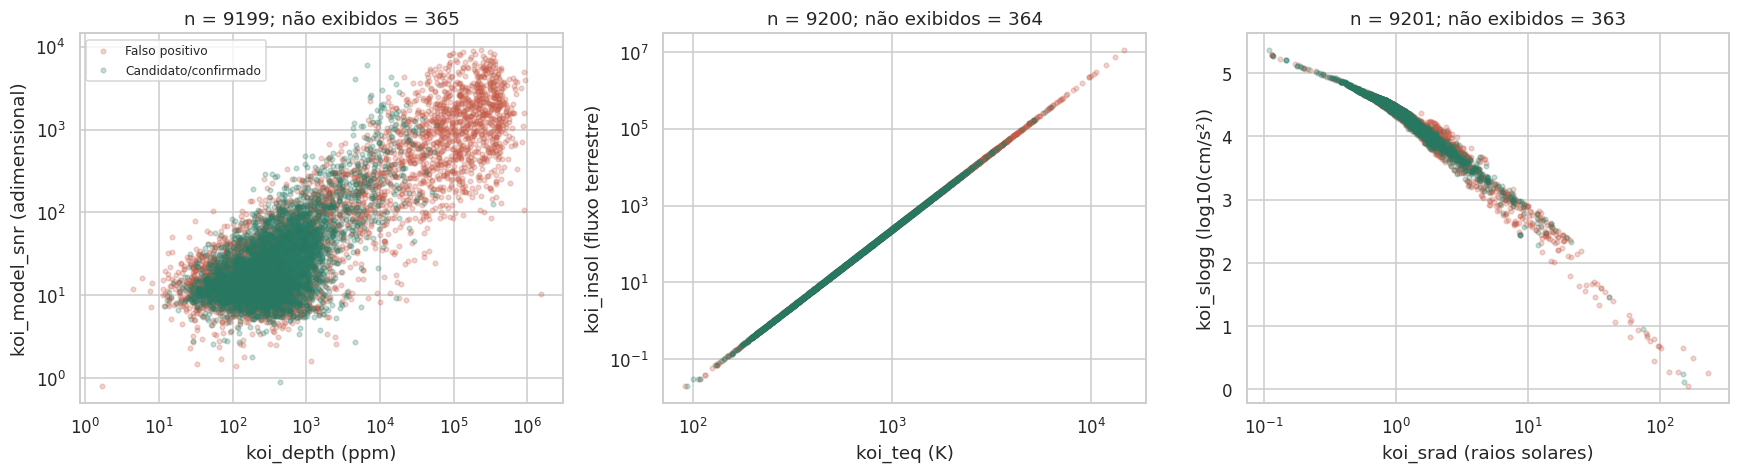

Medianas por classe (0 = falso positivo; 1 = candidato/confirmado):


target,0,1
koi_period,5.244,13.367
koi_impact,0.675,0.386
koi_duration,4.057,3.537
koi_depth,575.950,356.800
koi_prad,8.970,2.010
koi_teq,1152.500,752.000
koi_steff,5867.000,5657.000
koi_slogg,4.431,4.450
koi_srad,1.010,0.974
koi_insol,424.010,75.600


In [ ]:
pares_grafico = [
    ('koi_depth', 'koi_model_snr', True, True),
    ('koi_teq', 'koi_insol', True, True),
    ('koi_srad', 'koi_slogg', True, False)
]
fig, eixos = plt.subplots(1, 3, figsize=(16, 4.5))
for eixo, (x, y, log_x, log_y) in zip(eixos, pares_grafico):
    dados = df[[x, y, 'target']].dropna()
    if log_x:
        dados = dados[dados[x] > 0]
    if log_y:
        dados = dados[dados[y] > 0]
    for classe, cor, nome in [(0, '#C65A46', 'Falso positivo'),
                              (1, '#287A64', 'Candidato/confirmado')]:
        parte = dados[dados['target'] == classe]
        eixo.scatter(parte[x], parte[y], s=9, alpha=0.25, color=cor, label=nome)
    if log_x:
        eixo.set_xscale('log')
    if log_y:
        eixo.set_yscale('log')
    eixo.set_xlabel(f'{x} ({unidades[x]})')
    eixo.set_ylabel(f'{y} ({unidades[y]})')
    eixo.set_title(f'n = {len(dados)}; não exibidos = {len(df) - len(dados)}')
eixos[0].legend(fontsize=8)
plt.tight_layout()
plt.show()

print('Medianas por classe (0 = falso positivo; 1 = candidato/confirmado):')
display(df.groupby('target')[colunas_fisicas].median().T.round(3))

- **Profundidade × sinal-ruído:** a tendência crescente é compatível com a associação positiva observada no heatmap. As classes se sobrepõem, e sinais profundos/intensos também aparecem entre falsos positivos. Uma regra baseada apenas na intensidade seria insuficiente.
- **Temperatura de equilíbrio × insolação:** os pontos formam uma faixa muito estreita em escala logarítmica, reforçando a relação entre essas estimativas. O gráfico explica por que uma associação forte pode não aparecer como Pearson próximo de 1 na escala original. Para a modelagem, isso motiva comparar o uso conjunto dessas variáveis com alternativas que evitem informação redundante.
- **Raio × gravidade estelar:** a tendência é inversa e há sobreposição entre classes. A relação entre atributos não equivale a separação do alvo; uma correlação forte entre entradas não é, sozinha, motivo para mantê-las ou removê-las de um modelo.

As medianas complementam os gráficos: falsos positivos têm raio estimado mediano de **8,97**, contra **2,01 raios terrestres** na classe positiva; as temperaturas de equilíbrio medianas são **1.152,5 K e 752 K**, respectivamente. São diferenças exploratórias, não evidência de desempenho de um classificador.

## 7. Diagnóstico dos dados
### Valores ausentes — base completa
Quantificamos ausências nas 153 colunas, sem aplicar correções. A tabela completa fica disponível na saída, pois a exploração detalhada de 12 atributos não substitui o diagnóstico da base original.

In [ ]:
quantidade_ausentes = df_bruto.isna().sum()
tabela_ausentes = pd.DataFrame({
    'Quantidade': quantidade_ausentes,
    'Percentual (%)': quantidade_ausentes / len(df_bruto) * 100
}).sort_values('Quantidade', ascending=False)
print('Colunas com ausências:', (quantidade_ausentes > 0).sum())
print('Colunas totalmente vazias:', (quantidade_ausentes == len(df_bruto)).sum())
with pd.option_context('display.max_rows', None):
    display(tabela_ausentes[tabela_ausentes['Quantidade'] > 0].round(2))

ausentes_por_registro = df_bruto.isna().sum(axis=1)
print('Ausências por registro — mínimo, mediana e máximo:')
print(ausentes_por_registro.min(), ausentes_por_registro.median(), ausentes_por_registro.max())

colunas_ausencias_iguais = ['koi_impact', 'koi_depth', 'koi_prad', 'koi_teq',
                          'koi_steff', 'koi_slogg', 'koi_srad', 'koi_model_snr']
ausencias_grupo = df_bruto[colunas_ausencias_iguais].isna()
print('Ausência em pelo menos um dos oito atributos:', ausencias_grupo.any(axis=1).sum())
print('Ausência nos oito atributos:', ausencias_grupo.all(axis=1).sum())
display((ausencias_grupo.groupby(df_bruto['koi_disposition']).mean() * 100).round(2))

Colunas com ausências: 128
Colunas totalmente vazias: 24


,Quantidade,Percentual (%)
koi_gmag_err,9564,100.00
koi_imag_err,9564,100.00
koi_zmag_err,9564,100.00
koi_rmag_err,9564,100.00
koi_kepmag_err,9564,100.00
koi_longp_err2,9564,100.00
koi_sage_err2,9564,100.00
koi_sage_err1,9564,100.00
koi_sage,9564,100.00
koi_sma_err1,9564,100.00


Ausências por registro — mínimo, mediana e máximo:
24 25.0 120
Ausência em pelo menos um dos oito atributos: 363
Ausência nos oito atributos: 363


,koi_impact,koi_depth,koi_prad,koi_teq,koi_steff,koi_slogg,koi_srad,koi_model_snr
koi_disposition,,,,,,,,
CANDIDATE,5.26,5.26,5.26,5.26,5.26,5.26,5.26,5.26
CONFIRMED,0.07,0.07,0.07,0.07,0.07,0.07,0.07,0.07
FALSE POSITIVE,5.31,5.31,5.31,5.31,5.31,5.31,5.31,5.31


**128 colunas** têm ausências: **24 totalmente vazias** e **104 parcialmente preenchidas**. As outras 25 não têm ausências. Por registro, o mínimo é 24, a mediana 25 e o máximo 120. As 24 colunas vazias explicam o mínimo; desconsiderando-as, a mediana seria uma ausência por registro.

Os oito atributos investigados estão ausentes **nos mesmos 363 registros**. As proporções dentro das classes são **5,26% dos candidatos**, **0,07% dos confirmados** e **5,31% dos falsos positivos**. A falta de informação não está distribuída igualmente entre as categorias; remover esses registros poderia alterar sua representação. A ocorrência conjunta não comprova a causa das ausências.

`kepler_name` tem **71,27%** de ausências. Por ser um nome associado à confirmação, sua falta não deve ser tratada como a ausência de uma medida física nem preenchida automaticamente. Já `koi_kepmag` tem apenas uma ausência. A escolha de tratamento precisa considerar a função de cada campo.

As colunas totalmente vazias são candidatas à exclusão futura; não há observações nelas para estimar média ou mediana. Excluir agora todas as linhas com algum valor ausente eliminaria toda a base. **Nenhuma remoção ou imputação foi aplicada.**

### Duplicatas e colunas constantes
Verificamos linhas integralmente repetidas, repetição do identificador do objeto e colunas com um único valor observado. Uma coluna totalmente vazia é contabilizada separadamente de uma coluna constante entre seus valores presentes.

In [ ]:
print('Linhas integralmente duplicadas:', df_bruto.duplicated().sum())
print('Identificadores de objeto repetidos:', df_bruto['kepoi_name'].duplicated().sum())

valores_distintos = df_bruto.nunique(dropna=True)
colunas_constantes = valores_distintos[valores_distintos == 1].index
print('Colunas constantes entre valores observados:', len(colunas_constantes))
display(pd.DataFrame({
    'Coluna': colunas_constantes,
    'Quantidade de ausentes': df_bruto[colunas_constantes].isna().sum().values
}))
print('Atributos físicos constantes:', list(set(colunas_fisicas) & set(colunas_constantes)))

Linhas integralmente duplicadas: 0
Identificadores de objeto repetidos: 0
Colunas constantes entre valores observados: 11


,Coluna,Quantidade de ausentes
0,ra_err,0
1,dec_err,0
2,koi_delivname,0
3,koi_vet_stat,0
4,koi_limbdark_mod,363
5,koi_ldm_coeff4,363
6,koi_ldm_coeff3,363
7,koi_trans_mod,363
8,koi_eccen,363
9,koi_vet_date,0


Atributos físicos constantes: []


Não há linhas integralmente duplicadas nem repetição de `kepoi_name`. Identificamos **11 colunas constantes entre os valores observados**, como `ra_err`, `dec_err` e `koi_eccen`. Nenhum dos 12 atributos físicos examinados é constante.

Para colunas numéricas constantes, a variância dos valores presentes é nula. Elas não distinguem registros por seus valores, mas algumas ainda possuem ausências, cujo padrão deve ser considerado separadamente. Constância não comprova uma lei física: pode refletir decisões de ajuste ou de catalogação. A exclusão dessas colunas será uma hipótese de pré-processamento.

### Outliers e valores que exigem inspeção
Para quantificar extremos nos 12 atributos, usamos o intervalo interquartil **IQR = Q3 − Q1**. Sinalizamos valores abaixo de **Q1 − 1,5 × IQR** ou acima de **Q3 + 1,5 × IQR**, na escala original. O percentual usa como denominador a quantidade de valores presentes de cada atributo.

O critério é estatístico: distribuições assimétricas podem produzir muitos casos sinalizados. Não removemos esses pontos nem classificamos automaticamente todos como erros.

In [ ]:
dados_numericos = df[colunas_fisicas]
q1 = dados_numericos.quantile(0.25)
q3 = dados_numericos.quantile(0.75)
iqr = q3 - q1
limite_inferior = q1 - 1.5 * iqr
limite_superior = q3 + 1.5 * iqr
marcacao_outliers = (dados_numericos < limite_inferior) | (dados_numericos > limite_superior)

tabela_outliers = pd.DataFrame({
    'Valores presentes': dados_numericos.count(),
    'Sinalizados pelo IQR': marcacao_outliers.sum(),
    'Percentual (%)': marcacao_outliers.sum() / dados_numericos.count() * 100,
    'Limite inferior': limite_inferior,
    'Limite superior': limite_superior
})
display(tabela_outliers.round(3))

print('Verificações exploratórias de domínio:')
print('Profundidade maior que 1.000.000 ppm:', (df['koi_depth'] > 1000000).sum())
print('Profundidade igual a zero:', (df['koi_depth'] == 0).sum())
print('Sinal-ruído igual a zero:', (df['koi_model_snr'] == 0).sum())
print('Insolação igual a zero:', (df['koi_insol'] == 0).sum())
print('Valores negativos nos 12 atributos examinados:')
print((dados_numericos < 0).sum())
print('Valores infinitos nos 12 atributos:', np.isinf(dados_numericos).sum().sum())

print('Cinco maiores estimativas de raio, para inspeção:')
display(df.nlargest(5, 'koi_prad')[
    ['kepoi_name', 'koi_disposition', 'koi_prad', 'koi_impact', 'koi_depth']
])

,Valores presentes,Sinalizados pelo IQR,Percentual (%),Limite inferior,Limite superior
koi_period,9564,1567,16.384,-54.239,97.687
koi_impact,9201,82,0.891,-0.841,1.927
koi_duration,9564,869,9.086,-3.320,12.035
koi_depth,9201,1798,19.541,-1810.350,3443.650
koi_prad,9201,1469,15.966,-18.895,35.225
koi_teq,9201,411,4.467,-721.000,2639.000
koi_steff,9201,552,5.999,4107.000,7315.000
koi_slogg,9201,663,7.206,3.730,5.030
koi_srad,9201,985,10.705,0.055,2.119
koi_insol,9243,1438,15.558,-1255.060,2145.500


Verificações exploratórias de domínio:
Profundidade maior que 1.000.000 ppm: 1
Profundidade igual a zero: 1
Sinal-ruído igual a zero: 2
Insolação igual a zero: 1
Valores negativos nos 12 atributos examinados:
koi_period       0
koi_impact       0
koi_duration     0
koi_depth        0
koi_prad         0
koi_teq          0
koi_steff        0
koi_slogg        0
koi_srad         0
koi_insol        0
koi_model_snr    0
koi_kepmag       0
dtype: int64
Valores infinitos nos 12 atributos: 0
Cinco maiores estimativas de raio, para inspeção:


,kepoi_name,koi_disposition,koi_prad,koi_impact,koi_depth
8893,K06604.01,FALSE POSITIVE,200346.0,100.1960,2059.6
8747,K07251.01,FALSE POSITIVE,161858.0,88.7243,1364.2
7151,K05873.01,CANDIDATE,109061.0,86.1724,937.0
8529,K06704.01,FALSE POSITIVE,64333.8,100.8060,5732.0
6336,K05214.01,FALSE POSITIVE,46743.4,99.8500,1706.0


O IQR sinaliza **1.798 valores de profundidade**, **1.600 de sinal-ruído** e **1.567 de período orbital**. A quantidade elevada é compatível com as caudas observadas e reforça que uma exclusão automática pode retirar informação relevante.

Há **um valor de profundidade acima de 1.000.000 ppm**, correspondente a uma perda superior a 100% do fluxo na interpretação direta da grandeza. Ele exige investigação do ajuste ou registro. Também há profundidade zero (um caso), sinal-ruído zero (dois) e insolação zero (um). Esses zeros merecem investigação, mas não declaramos todos inválidos sem examinar sua origem.

As maiores estimativas de raio são mostradas com seus identificadores e classificações para permitir rastreá-las. Um extremo pode refletir um ajuste inadequado à hipótese planetária ou características de um falso positivo. Nenhum ponto foi removido. Estas verificações cobrem os atributos físicos examinados; não constituem uma validação de domínio de todos os 153 campos.

## 8. Discussão inicial e próximos passos
O diagnóstico encontrou uma base de tamanho suficiente, alvo binário próximo do equilíbrio, ausências conjuntas, distribuições assimétricas e relações fortes entre alguns atributos. As principais hipóteses para a próxima etapa são:

| Evidência | Hipótese de pré-processamento a avaliar |
|---|---|
| 24 colunas totalmente vazias e 11 constantes entre valores presentes | Avaliar exclusão com registro das dimensões resultantes |
| Ausências físicas concentradas nos mesmos objetos e com proporções diferentes por classe | Comparar imputação e estratégias de uso dos registros; avaliar possível informação do padrão de ausência |
| Caudas extensas e escalas muito diferentes | Comparar transformação de escala e padronização/escalonamento apropriado, principalmente para métodos sensíveis à distância |
| Extremos e possíveis inconsistências | Inspecionar os registros antes de decidir preservar, corrigir ou remover |
| Relações fortes entre temperatura e insolação, e entre gravidade e raio estelar | Investigar seleção de atributos; redução dimensional apenas se houver justificativa |
| Classes com 50,60% e 49,40% | Não há indicação inicial de balanceamento; reavaliar após qualquer recorte |
| Recorte de 12 entradas contínuas; campos nominais descritos apenas para contexto | Não é necessário codificar categorias nessas 12 entradas; se o recorte mudar, avaliar codificação nominal e possível vazamento |
| Métodos de ajuste e origens dos parâmetros variam entre registros | Investigar essa procedência antes de atribuir extremos ou ausências apenas a erros de coleta |
| Mais de um objeto associado à mesma estrela | Considerar validação cruzada com agrupamento por `kepid` e examinar as proporções das classes nos folds |

Estas são hipóteses, não resultados de comparação entre modelos. Na etapa experimental, os tratamentos que aprendem parâmetros deverão ser ajustados somente nos dados de treinamento de cada fold. O projeto geral solicita validação cruzada **10-fold**, a ser aplicada na etapa experimental. A Entrega 1 termina no diagnóstico e nas hipóteses de tratamento; não inclui treinamento ou validação de modelos.

**Dimensões preservadas nesta EDA:** 9.564 registros, 153 colunas originais e 12 atributos físicos na exploração detalhada. Identificadores e alvo não contam como os 12 atributos. Qualquer recorte futuro deve ser justificado e ter suas dimensões explicitadas.

**Limitações:** candidatos não equivalem a planetas confirmados; parte dos parâmetros depende de ajustes; o catálogo não representa todas as estrelas; correlações e diferenças visuais não demonstram desempenho preditivo.

## Referências
- [NASA Exoplanet Archive — KOI Cumulative](https://exoplanetarchive.ipac.caltech.edu/cgi-bin/TblView/nph-tblView?app=ExoTbls&config=cumulative). DOI: 10.26133/NEA4.
- [Dicionário de dados da tabela KOI](https://exoplanetarchive.ipac.caltech.edu/docs/API_kepcandidate_columns.html).
- [Acesso aos dados pelo serviço TAP](https://exoplanetarchive.ipac.caltech.edu/docs/TAP/usingTAP.html).
- [Orientações de reconhecimento de uso do arquivo](https://exoplanetarchive.ipac.caltech.edu/docs/acknowledge.html).